In [7]:
import pandas as pd
from pathlib import Path
import numpy as np

# Find repo root
repo_root = Path.cwd()
for candidate in [repo_root] + list(repo_root.parents):
    if (candidate / 'pyproject.toml').exists() or (candidate / '.git').exists():
        repo_root = candidate
        break

print('Repo root:', repo_root)

# Read the berkhout file with semicolon separator
file_path = repo_root / 'input_stressors' / 'uurgeg_249_2021-2030_3_maart.csv'
df = pd.read_csv(file_path, sep=';')

print(f'File loaded: {file_path.name}')
print(f'Shape: {df.shape}')
print(f'\nFirst few rows:')
print(df.head())
print(f'\nColumn names:')
print(df.columns.tolist())
print(f'\nData types:')
print(df.dtypes)

Repo root: d:\Users\jvanruitenbeek\data_validation
File loaded: uurgeg_249_2021-2030_3_maart.csv
Shape: (45288, 27)

First few rows:
   # STN  YYYYMMDD     HH    DD    FH    FF    FX      T   T10N     TD  ...  \
0    249  20210101      1   260    10    10    20     -5            -9  ...   
1    249  20210101      2   240    10    20    20     -5           -10  ...   
2    249  20210101      3   230    20    20    30      4            -4  ...   
3    249  20210101      4   230    30    30    30     12             2  ...   
4    249  20210101      5   320    20    20    50     12             4  ...   

       U     WW     IX      M     R     S     O      Y Unnamed: 25  \
0     97     10      7      0     0     0     0      0         NaN   
1     96     10      7      0     0     0     0      0         NaN   
2     94     10      7      0     0     0     0      0         NaN   
3     93     10      7      0     0     0     0      0         NaN   
4     94     51      7      0     1     0 

C:\Users\jvanruitenbeek\AppData\Local\Temp\9\ipykernel_1580\1164549016.py:16: DtypeWarning: Columns (3,4,5,6,20,21,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=';')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45288 entries, 0 to 45287
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   # STN        45288 non-null  int64  
 1   YYYYMMDD     45288 non-null  int64  
 2      HH        45288 non-null  int64  
 3      DD        45288 non-null  object 
 4      FH        45288 non-null  object 
 5      FF        45288 non-null  object 
 6      FX        45288 non-null  object 
 7       T        45288 non-null  int64  
 8    T10N        45288 non-null  object 
 9      TD        45288 non-null  int64  
 10     SQ        45288 non-null  int64  
 11      Q        45288 non-null  int64  
 12     DR        45288 non-null  int64  
 13     RH        45288 non-null  int64  
 14      P        45288 non-null  object 
 15     VV        45288 non-null  object 
 16      N        45288 non-null  object 
 17      U        45288 non-null  int64  
 18     WW        45288 non-null  object 
 19     I

In [9]:
# 2. Kolomnamen opschonen
df.columns = [c.strip() for c in df.columns]

# 3. Timestamp maken (begin van het uur)
# Convert YYYYMMDD to date and HH to integer hours. Handles HH=24 (next day's 00:00).
df['YYYYMMDD'] = df['YYYYMMDD'].astype(str).str.strip()
df['HH'] = pd.to_numeric(df['HH'], errors='coerce').fillna(0).astype(int)
# Parse date and add hours as timedelta (HH=24 -> +24h -> next day 00:00)
df['date'] = pd.to_datetime(df['YYYYMMDD'], format='%Y%m%d', errors='coerce')
df['timestamp'] = df['date'] + pd.to_timedelta(df['HH'], unit='h')
df = df.set_index('timestamp').sort_index()

# clean up temporary column
df = df.drop(columns=['date'])

In [10]:
import matplotlib.pyplot as plt

# RH: 0.1 mm → mm, -1 = <0.05 mm → 0
df['rain_mm'] = df['RH'].where(df['RH'] >= 0, 0) / 10.0

daily_rain = df['rain_mm'].resample('D').sum()

# Printing yearly sum 
print(daily_rain.resample('YE').sum())

timestamp
2021-12-31     851.6
2022-12-31     737.0
2023-12-31    1127.7
2024-12-31    1050.4
2025-12-31     737.8
2026-12-31     126.8
Freq: YE-DEC, Name: rain_mm, dtype: float64


In [11]:
cumsum_rain = daily_rain.cumsum()

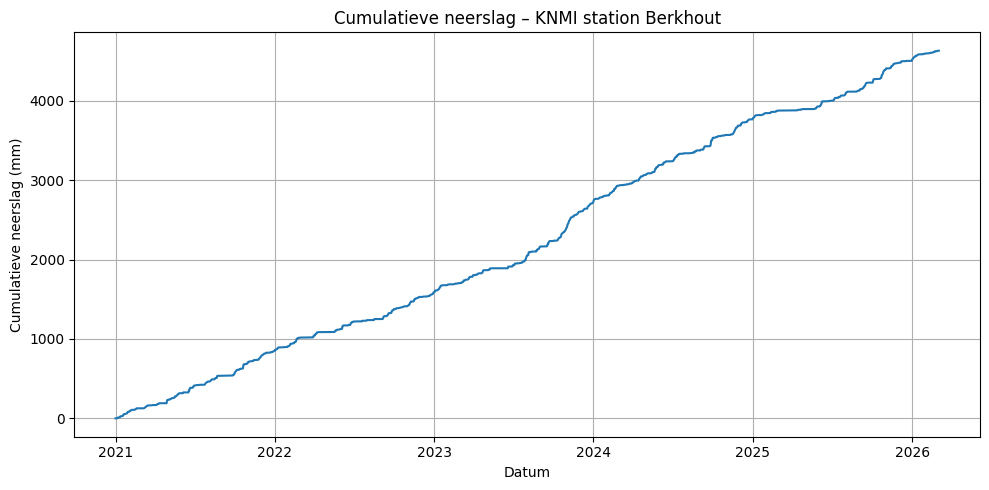

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(cumsum_rain.index, cumsum_rain.values)
plt.xlabel("Datum")
plt.ylabel("Cumulatieve neerslag (mm)")
plt.title("Cumulatieve neerslag – KNMI station Berkhout")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
rain_df = (
    df[['rain_mm']]
    .rename(columns={'rain_mm': 'rain_mm_per_hour'})
    .reset_index()
)

rain_df.to_csv("knmi_berkhout_hourly_rain_mm.csv", index=False)

# Calculating Makkink and converting to .csv for pastas

In [14]:
# 5. Makkink verdamping in mm/uur
df['T'] = pd.to_numeric(df['T'], errors='coerce')
df['Q'] = pd.to_numeric(df['Q'], errors='coerce')

# Temperatuur
df['T_C'] = df['T'] / 10.0          # 0.1 °C → °C

# Globale straling
df['Rs_MJ'] = df['Q'].clip(lower=0) * 0.01   # J/cm² → MJ/m² (per uur)

# Makkink-parameters
gamma = 0.066                       # kPa/°C
lambda_MJ = 2.45                   # MJ/m² per mm verdamping

T = df['T_C']                      # laat NaN staan
delta = (
    4098
    * (0.6108 * np.exp((17.27 * T) / (T + 237.3)))
    / ((T + 237.3) ** 2)
)

# Makkink verdamping (mm per uur)
df['makkink_mm'] = (
    0.65
    * (delta / (delta + gamma))
    * (df['Rs_MJ'] / lambda_MJ)
)

# Opslaan
evap_df = df[['makkink_mm']]
evap_df.to_csv('knmi_berkhout_hourly_makkink.csv')

In [15]:
# Jaarlijkse som verdamping (mm/jaar)
annual_evap = df['makkink_mm'].resample('YE').sum()

print("Jaarlijkse Makkink-verdamping (mm):")
print(annual_evap)

print("\nGemiddeld per jaar (mm):")
print(annual_evap.mean())


Jaarlijkse Makkink-verdamping (mm):
timestamp
2021-12-31    639.369025
2022-12-31    740.806139
2023-12-31    685.106234
2024-12-31    663.390385
2025-12-31    733.395558
2026-12-31     28.815535
Freq: YE-DEC, Name: makkink_mm, dtype: float64

Gemiddeld per jaar (mm):
581.8138126707415


# Penman Monteith

In [16]:
import numpy as np
import pandas as pd

# ---------------------------
# Helpers (FAO-56)
# ---------------------------
def esat_kpa(Tc: pd.Series) -> pd.Series:
    return 0.6108 * np.exp((17.27 * Tc) / (Tc + 237.3))

def slope_delta_kpa_per_c(Tc: pd.Series) -> pd.Series:
    es = esat_kpa(Tc)
    return 4098.0 * es / ((Tc + 237.3) ** 2)

def wind_10m_to_2m(u10: pd.Series) -> pd.Series:
    z = 10.0
    return u10 * 4.87 / np.log(67.8 * z - 5.42)

def quick_stats(name: str, s: pd.Series):
    s_num = pd.to_numeric(s, errors='coerce')
    print(f"\n{name}")
    print("  non-null:", int(s_num.notna().sum()), "van", len(s_num))
    if s_num.notna().any():
        print("  min/median/max:", float(s_num.min()), float(s_num.median()), float(s_num.max()))

def parse_pressure_to_kpa_or_fallback(P_col: pd.Series, fallback_kpa=101.3):
    """
    Try parse pressure from KNMI column P. If parsing fails completely, fallback to constant kPa.
    Returns (P_kPa_series, used_source_string).
    """
    P_str = P_col.astype(str).str.strip()
    P_str = P_str.replace({"": np.nan, "nan": np.nan, "None": np.nan, "---": np.nan, "-": np.nan})
    P_raw = pd.to_numeric(P_str, errors="coerce")

    if P_raw.notna().sum() == 0:
        # fallback
        P_kPa = pd.Series(fallback_kpa, index=P_col.index, dtype="float64")
        return P_kPa, f"fallback constant {fallback_kpa} kPa (P kolom niet parsebaar)"
    
    # auto-detect schaal
    P_med = P_raw.median(skipna=True)
    if P_med > 2000:          # 0.1 hPa
        P_kPa = (P_raw / 10.0) / 10.0
        src = "parsed as 0.1 hPa -> kPa"
    elif P_med > 200:         # hPa
        P_kPa = P_raw / 10.0
        src = "parsed as hPa -> kPa"
    else:                     # kPa
        P_kPa = P_raw
        src = "parsed as kPa"
    return P_kPa, src

# ---------------------------
# Penman–Monteith ET0 (hourly)
# ---------------------------

assert isinstance(df.index, pd.DatetimeIndex), "df.index moet een DatetimeIndex zijn (timestamp)."
df = df.sort_index()

# 1) Inputs & unit conversions
Tc = pd.to_numeric(df['T'], errors='coerce') / 10.0          # 0.1°C -> °C
RH = pd.to_numeric(df['U'], errors='coerce')                 # %
u10 = pd.to_numeric(df['FF'], errors='coerce') / 10.0        # 0.1 m/s -> m/s
Rs = pd.to_numeric(df['Q'], errors='coerce').clip(lower=0) * 0.01  # J/cm² -> MJ/m² per uur

# Pressure (parse or fallback)
P_kPa, P_src = parse_pressure_to_kpa_or_fallback(df['P'], fallback_kpa=101.3)

# Input sanity
print("=== INPUT SANITY ===")
quick_stats("T (°C)", Tc)
quick_stats("RH (%)", RH)
quick_stats("Wind u10 (m/s)", u10)
quick_stats("Rs (MJ/m²/uur)", Rs)
quick_stats("P (kPa)", P_kPa)
print("\nPressure source:", P_src)

# 2) Psychrometric constant gamma (kPa/°C)
gamma = 0.000665 * P_kPa

# 3) Vapour pressures
es = esat_kpa(Tc)
ea = (RH.clip(0, 100) / 100.0) * es
vpd = (es - ea).clip(lower=0)

# 4) Delta
delta = slope_delta_kpa_per_c(Tc)

# 5) Net radiation (stabiele benadering)
albedo = 0.23
Rns = (1 - albedo) * Rs  # MJ/m²/uur

Tk = Tc + 273.15
sigma_day = 4.903e-9
sigma_h = sigma_day / 24.0

cloud_factor = 0.75
Rnl = sigma_h * (Tk ** 4) * (0.34 - 0.14 * np.sqrt(ea.clip(lower=0))) * cloud_factor
Rnl = Rnl.clip(lower=0)

Rn = (Rns - Rnl)

# 6) Soil heat flux G
is_day = Rs > 0.01
G = np.where(is_day, 0.1 * Rn, 0.5 * Rn)

# 7) Wind at 2m
u2 = wind_10m_to_2m(u10).clip(lower=0)

# 8) ET0 (mm/uur)
ET0 = (
    (0.408 * delta * (Rn - G) + gamma * (37.0 / (Tc + 273.0)) * u2 * vpd)
    / (delta + gamma * (1 + 0.34 * u2))
)

df['et0_pm_mm'] = ET0.clip(lower=0)

# Output sanity
print("\n=== OUTPUT SANITY ===")
print("ET0 non-null:", int(df['et0_pm_mm'].notna().sum()), "van", len(df))
print("ET0 (mm/uur) min/median/max:",
      float(df['et0_pm_mm'].min(skipna=True)),
      float(df['et0_pm_mm'].median(skipna=True)),
      float(df['et0_pm_mm'].max(skipna=True)))

# Jaarlijkse sommen (min_count=1 om NaN niet als 0 te maskeren)
annual_pm = df['et0_pm_mm'].resample('YE').sum(min_count=1)
print("\nJaarlijkse Penman–Monteith ET0 (mm/jaar):")
print(annual_pm)

total_pm = df['et0_pm_mm'].sum(min_count=1)
print("\nTotaal periode (mm):", float(total_pm))
print("Gemiddeld per jaar (mm/jaar):", float(annual_pm.mean(skipna=True)))

# Opslaan
df[['et0_pm_mm']].to_csv("knmi_berkhout_hourly_penman_monteith_et0.csv")
print("\nSaved Penman–Monteith ET0 to CSV!")

=== INPUT SANITY ===

T (°C)
  non-null: 45288 van 45288
  min/median/max: -9.7 10.6 33.7

RH (%)
  non-null: 45288 van 45288
  min/median/max: 29.0 86.0 100.0

Wind u10 (m/s)
  non-null: 45237 van 45288
  min/median/max: 0.0 4.0 22.0

Rs (MJ/m²/uur)
  non-null: 45288 van 45288
  min/median/max: 0.0 0.02 3.35

P (kPa)
  non-null: 45288 van 45288
  min/median/max: 101.3 101.3 101.3

Pressure source: fallback constant 101.3 kPa (P kolom niet parsebaar)

=== OUTPUT SANITY ===
ET0 non-null: 45237 van 45288
ET0 (mm/uur) min/median/max: 0.0 0.014323839962679897 0.7064962758170626

Jaarlijkse Penman–Monteith ET0 (mm/jaar):
timestamp
2021-12-31    556.666813
2022-12-31    697.454766
2023-12-31    635.821216
2024-12-31    604.125786
2025-12-31    689.693446
2026-12-31     22.747911
Freq: YE-DEC, Name: et0_pm_mm, dtype: float64

Totaal periode (mm): 3206.5099389500338
Gemiddeld per jaar (mm/jaar): 534.4183231583389

Saved Penman–Monteith ET0 to CSV!


C:\Users\jvanruitenbeek\AppData\Local\Temp\9\ipykernel_1580\2791289060.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  P_str = P_str.replace({"": np.nan, "nan": np.nan, "None": np.nan, "---": np.nan, "-": np.nan})


# Hargreaves

In [17]:
# Check of T echt in 0.1°C zit (typisch -200..400 in NL uurdata)
T_raw = pd.to_numeric(df['T'], errors='coerce')
print("T_raw stats (KNMI eenheid):")
print(T_raw.describe())

T_C = T_raw / 10.0
print("\nT_C stats (°C):")
print(T_C.describe())

# Kijk naar extreme dagen
T_C_clean = T_C.where((T_C > -50) & (T_C < 60))
daily_tmp = pd.DataFrame({
    "Tmin": T_C_clean.resample("D").min(),
    "Tmax": T_C_clean.resample("D").max(),
    "Tmean": T_C_clean.resample("D").mean(),
})
daily_tmp["Trange"] = daily_tmp["Tmax"] - daily_tmp["Tmin"]

print("\nTop 10 dagen met grootste Trange:")
print(daily_tmp.sort_values("Trange", ascending=False).head(10))

T_raw stats (KNMI eenheid):
count    45288.000000
mean       108.352897
std         63.513050
min        -97.000000
25%         62.000000
50%        106.000000
75%        156.000000
max        337.000000
Name: T, dtype: float64

T_C stats (°C):
count    45288.000000
mean        10.835290
std          6.351305
min         -9.700000
25%          6.200000
50%         10.600000
75%         15.600000
max         33.700000
Name: T, dtype: float64

Top 10 dagen met grootste Trange:
            Tmin  Tmax      Tmean  Trange
timestamp                                
2025-05-01   6.9  25.7  17.295833    18.8
2021-03-31   4.0  21.9  12.641667    17.9
2025-04-30   6.0  23.3  14.787500    17.3
2025-04-12   3.3  20.5  13.508333    17.2
2021-03-30   3.7  20.6  11.425000    16.9
2022-06-23  12.6  29.2  21.379167    16.6
2025-04-04   3.2  19.8  11.425000    16.6
2025-05-10   4.7  21.1  14.129167    16.4
2023-06-11  13.8  30.2  23.662500    16.4
2024-08-28  11.6  27.9  20.070833    16.3


In [18]:
print(daily_tmp.sort_values("Trange", ascending=False).head(10))

            Tmin  Tmax      Tmean  Trange
timestamp                                
2025-05-01   6.9  25.7  17.295833    18.8
2021-03-31   4.0  21.9  12.641667    17.9
2025-04-30   6.0  23.3  14.787500    17.3
2025-04-12   3.3  20.5  13.508333    17.2
2021-03-30   3.7  20.6  11.425000    16.9
2022-06-23  12.6  29.2  21.379167    16.6
2025-04-04   3.2  19.8  11.425000    16.6
2025-05-10   4.7  21.1  14.129167    16.4
2023-06-11  13.8  30.2  23.662500    16.4
2024-08-28  11.6  27.9  20.070833    16.3


In [19]:
import numpy as np
import pandas as pd

assert isinstance(df.index, pd.DatetimeIndex), "df.index moet een DatetimeIndex zijn (timestamp)."
df = df.sort_index()


# --- 1) Temperatuur (0.1°C -> °C) + cleanup van missings/outliers ---
T_C = pd.to_numeric(df['T'], errors='coerce') / 10.0

# KNMI missings zijn vaak -9999 (=> -999.9°C) of andere onmogelijke waarden.
# Filter op plausibel bereik voor NL (ruim genomen)
T_C = T_C.where((T_C > -50) & (T_C < 60))

# --- 2) Dagwaarden alleen uit temperatuur afleiden ---
daily = pd.DataFrame(index=T_C.resample('D').mean().index)
daily['Tmean'] = T_C.resample('D').mean()
daily['Tmax']  = T_C.resample('D').max()
daily['Tmin']  = T_C.resample('D').min()

# Range (met vangnet)
daily['Trange'] = (daily['Tmax'] - daily['Tmin']).clip(lower=0)

# Extra vangnet: Trange in NL is zelden > 25–30°C. Outliers afkappen.
daily['Trange'] = daily['Trange'].clip(upper=30)

# Debug: check of Tmax/Tmin nog gek zijn
print("Tmax stats (°C):")
print(daily['Tmax'].describe())
print("\nTmin stats (°C):")
print(daily['Tmin'].describe())
print("\nTrange stats (°C):")
print(daily['Trange'].describe())

# --- 3) Ra (extraterrestrische straling) per dag ---
lat_deg = 52.644  # Berkhout
phi = np.deg2rad(lat_deg)
J = daily.index.dayofyear.to_numpy()

Gsc = 0.0820  # MJ m-2 min-1
dr = 1 + 0.033 * np.cos(2 * np.pi * J / 365.0)
decl = 0.409 * np.sin(2 * np.pi * J / 365.0 - 1.39)
ws = np.arccos(np.clip(-np.tan(phi) * np.tan(decl), -1, 1))

Ra = (24 * 60 / np.pi) * Gsc * dr * (
    ws * np.sin(phi) * np.sin(decl) +
    np.cos(phi) * np.cos(decl) * np.sin(ws)
)  # MJ m-2 d-1

daily['Ra'] = Ra

# --- 4) Hargreaves–Samani ET0 (mm/d) — GECALIBREERD VOOR NL ---
k_NL = 0.55   # maritiem klimaat (NL)

daily['ET0_HS_mm_d'] = (
    k_NL
    * 0.0023
    * (daily['Tmean'] + 17.8).clip(lower=0)
    * np.sqrt(daily['Trange'])
    * daily['Ra']
).clip(lower=0)

# --- 5) Jaarlijkse som ---
annual_hs = daily['ET0_HS_mm_d'].resample('YE').sum(min_count=1)

print("\nJaarlijkse Hargreaves–Samani ET0 (NL-gekalibreerd) (mm/jaar):")
print(annual_hs)

print("\nGemiddeld per jaar (mm/jaar):", annual_hs.mean())

Tmax stats (°C):
count    1888.000000
mean       14.156197
std         6.650032
min        -3.000000
25%         9.200000
50%        13.900000
75%        19.500000
max        33.700000
Name: Tmax, dtype: float64

Tmin stats (°C):
count    1888.000000
mean        7.189936
std         5.419949
min        -9.700000
25%         2.975000
50%         7.350000
75%        11.600000
max        19.900000
Name: Tmin, dtype: float64

Trange stats (°C):
count    1888.000000
mean        6.966261
std         3.333198
min         0.000000
25%         4.400000
50%         6.600000
75%         9.100000
max        18.800000
Name: Trange, dtype: float64

Jaarlijkse Hargreaves–Samani ET0 (NL-gekalibreerd) (mm/jaar):
timestamp
2021-12-31    875.833788
2022-12-31    978.652394
2023-12-31    921.706159
2024-12-31    913.686861
2025-12-31    975.731215
2026-12-31     35.721202
Freq: YE-DEC, Name: ET0_HS_mm_d, dtype: float64

Gemiddeld per jaar (mm/jaar): 783.5552698382348


In [20]:
(
    daily[['ET0_HS_mm_d']]
    .rename(columns={'ET0_HS_mm_d': 'Hargreaves'})
    .reset_index()
    .to_csv("knmi_berkhout_daily_hargreaves_samani.csv", index=False)
)

# Data compare

<Figure size 1000x500 with 0 Axes>

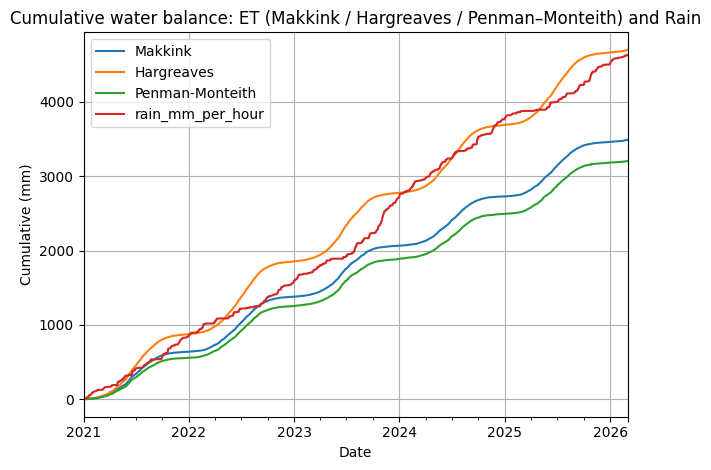

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Load series ----
makkink = pd.read_csv("knmi_berkhout_hourly_makkink.csv", parse_dates=[0], index_col=0)
hargreaves = pd.read_csv("knmi_berkhout_daily_hargreaves_samani.csv", parse_dates=[0], index_col=0)
penman = pd.read_csv("knmi_berkhout_hourly_penman_monteith_et0.csv", parse_dates=[0], index_col=0)
rain = pd.read_csv("knmi_berkhout_hourly_rain_mm.csv", parse_dates=[0], index_col=0)

# ---- Rename columns (fix names to match your actual CSV columns) ----
# Makkink file created earlier: column likely 'makkink_mm'
makkink = makkink.rename(columns={"makkink_mm": "Makkink"})

# Hargreaves daily file from the fixed code: column is 'ET0_HS_mm_d'
hargreaves = hargreaves.rename(columns={"ET0_HS_mm_d": "Hargreaves"})

# Penman file from the fixed code: column is 'et0_pm_mm'
penman = penman.rename(columns={"et0_pm_mm": "Penman-Monteith"})

# Rain file: column is 'rain_mm'
rain = rain.rename(columns={"rain_mm": "rain_mm_per_hour"})

# ---- Make everything daily totals (mm/day) ----
makkink_d = makkink["Makkink"].resample("D").sum(min_count=1)
penman_d = penman["Penman-Monteith"].resample("D").sum(min_count=1)
hargreaves_d = hargreaves["Hargreaves"]  # already daily (mm/day)
rain_d = rain["rain_mm_per_hour"].resample("D").sum(min_count=1)

# ---- Combine ----
df = pd.concat([makkink_d, hargreaves_d, penman_d, rain_d], axis=1)

# Optional: filter period
# df = df.loc["2024-01-01":"2024-12-31"]

# ---- Cumulative sums ----
df_cum = df.cumsum()

# ---- Plot ----
plt.figure(figsize=(10, 5))
df_cum.plot()
plt.ylabel("Cumulative (mm)")
plt.xlabel("Date")
plt.title("Cumulative water balance: ET (Makkink / Hargreaves / Penman–Monteith) and Rain")
plt.grid(True)
plt.tight_layout()
plt.show()
